# Fine-Tuned Sentence Transformer — Smart Job Search Using Deep Learning

This notebook finetunes a pretrained Sentence Transformer (all-MiniLM-L6-v2) for semantic resume to job matching and compares it against the Siamese LSTM baseline from Part 1.

**Model:**
- Pre-trained all-MiniLM-L6-v2: 6-layer transformer, 6 attention heads, 384-dim embeddings
- Pre-trained on 1B+ sentence pairs (Reimers & Gurevych, 2019), architecture from MiniLM (Wang et al., 2020)

**Training setup:**
- 40,000 resume job pairs with labels: 0.0 (unrelated), 0.5 (related), 1.0 (same category)
- CosineSimilarityLoss, AdamW optimizer (lr=2e-5), 10% warmup
- 20 epochs, batch size 32, data split 80/10/10

**Results:**
- Pre-trained accuracy (before fine-tuning): 33.2%
- Fine-tuned accuracy: 83.9%, MSE: 0.0669, Weighted F1: 0.84
- MRR: 0.9259, NDCG@10: 0.9371
- Improvement over LSTM baseline: +18.8 percentage points

In [ ]:
# Install & Import Libraries

import pandas as pd
import numpy as np
import re
import random
import json
import torch
import torch.nn as nn
import nltk
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from datetime import datetime

from sentence_transformers import SentenceTransformer, InputExample, losses, evaluation
from torch.utils.data import DataLoader
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.metrics.pairwise import cosine_similarity as cos_sim
from sklearn.metrics import ndcg_score

warnings.filterwarnings('ignore')
nltk.download('punkt', quiet=True)
nltk.download('stopwords', quiet=True)
nltk.download('punkt_tab', quiet=True)
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize



In [ ]:
# Set seeds for reproducibility

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
 
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")

Using device: cuda
GPU: NVIDIA GeForce RTX 5060 Ti


In [3]:
#  Load Data

RESUME_PATH = 'live_resume/Resume/Resume.csv'
JOB_PATH = 'linkedin_job/filtered_job_postings.csv'
 
resume_df = pd.read_csv(RESUME_PATH)
job_df = pd.read_csv(JOB_PATH)
 
job_text_col = 'job_description'
job_cat_col = 'Category'
 
print(f"Resumes loaded: {len(resume_df)} rows")
print(f"Jobs loaded: {len(job_df)} rows")
print(f"\nResume categories ({resume_df['Category'].nunique()}): {sorted(resume_df['Category'].unique())}")
print(f"Job categories ({job_df[job_cat_col].nunique()}): {sorted(job_df[job_cat_col].unique())}")

Resumes loaded: 2484 rows
Jobs loaded: 101492 rows

Resume categories (24): ['ACCOUNTANT', 'ADVOCATE', 'AGRICULTURE', 'APPAREL', 'ARTS', 'AUTOMOBILE', 'AVIATION', 'BANKING', 'BPO', 'BUSINESS-DEVELOPMENT', 'CHEF', 'CONSTRUCTION', 'CONSULTANT', 'DESIGNER', 'DIGITAL-MEDIA', 'ENGINEERING', 'FINANCE', 'FITNESS', 'HEALTHCARE', 'HR', 'INFORMATION-TECHNOLOGY', 'PUBLIC-RELATIONS', 'SALES', 'TEACHER']
Job categories (24): ['ACCOUNTANT', 'ADVOCATE', 'AGRICULTURE', 'APPAREL', 'ARTS', 'AUTOMOBILE', 'AVIATION', 'BANKING', 'BPO', 'BUSINESS-DEVELOPMENT', 'CHEF', 'CONSTRUCTION', 'CONSULTANT', 'DESIGNER', 'DIGITAL-MEDIA', 'ENGINEERING', 'FINANCE', 'FITNESS', 'HEALTHCARE', 'HR', 'INFORMATION-TECHNOLOGY', 'PUBLIC-RELATIONS', 'SALES', 'TEACHER']


## Text Preprocessing
Applies lighter cleaning than the LSTM version — transformers handle raw text better, so more structure is preserved. HTML tags, URLs, emails, and special characters are removed, but the cleaning is less aggressive to let the pre-trained tokenizer work effectively.

In [ ]:
#  Text Preprocessing (lighter than LSTM — transformer handles raw text better)

stop_words = set(stopwords.words('english'))
 
def clean_text(text):
    """Light cleaning for Sentence Transformer — preserve more structure than LSTM version."""
    if not isinstance(text, str):
        return ""
    text = re.sub(r'<[^>]+>', ' ', text)         # Remove HTML tags
    text = re.sub(r'http\S+|www\S+', ' ', text)   # Remove URLs
    text = re.sub(r'\S+@\S+', ' ', text)           # Remove emails
    text = re.sub(r'[^a-zA-Z0-9\s\.\,\-]', ' ', text)  # Keep letters, numbers, basic punctuation
    text = re.sub(r'\s+', ' ', text).strip()
    return text
 
def truncate_text(text, max_words=256):
    """Truncate to max_words — MiniLM has a 256 token limit for best performance."""
    words = text.split()[:max_words]
    return ' '.join(words)
 
print("Cleaning resume texts...")
resume_df['clean_text'] = resume_df['Resume_str'].apply(clean_text).apply(truncate_text)
 
print("Cleaning job description texts...")
job_df['clean_text'] = job_df[job_text_col].apply(clean_text).apply(truncate_text)
 
# Drop empty rows
resume_df = resume_df[resume_df['clean_text'].str.len() > 0].reset_index(drop=True)
job_df = job_df[job_df['clean_text'].str.len() > 0].reset_index(drop=True)
 
print(f"\nAfter cleaning — Resumes: {len(resume_df)}, Jobs: {len(job_df)}")
print(f"Sample resume (first 150 chars): {resume_df['clean_text'].iloc[0][:150]}")
print(f"Sample job (first 150 chars): {job_df['clean_text'].iloc[0][:150]}")

Cleaning resume texts...
Cleaning job description texts...

After cleaning — Resumes: 2483, Jobs: 101486
Sample resume (first 150 chars): HR ADMINISTRATOR MARKETING ASSOCIATE HR ADMINISTRATOR Summary Dedicated Customer Service Manager with 15 years of experience in Hospitality and Custom
Sample job (first 150 chars): The National Exemplar is accepting applications for an Assistant Restaurant Manager. We offer highly competitive wages, healthcare, paid time off, com


## Related Categories and Training Pair Generation
Uses the same category relationship mapping as baseline
- **1.0** — same category
- **0.5** — related categories
- **0.0** — unrelated categories


In [5]:
# Define Related Categories 

 
RELATED_CATEGORIES = {
    'Information-Technology': ['Engineering', 'Digital-Media', 'BPO', 'Consultant'],
    'Engineering': ['Information-Technology', 'Automobile', 'Aviation', 'Construction'],
    'Healthcare': ['Fitness', 'Agriculture'],
    'Finance': ['Accountant', 'Banking', 'Business-Development', 'Consultant'],
    'Accountant': ['Finance', 'Banking', 'Business-Development'],
    'Banking': ['Finance', 'Accountant', 'Business-Development'],
    'Sales': ['Business-Development', 'Public-Relations', 'Advocate', 'Consultant'],
    'Business-Development': ['Sales', 'Finance', 'Consultant', 'Public-Relations'],
    'Arts': ['Designer', 'Apparel', 'Digital-Media', 'Public-Relations'],
    'Designer': ['Arts', 'Apparel', 'Digital-Media'],
    'Digital-Media': ['Arts', 'Designer', 'Information-Technology', 'Public-Relations'],
    'Apparel': ['Arts', 'Designer'],
    'Aviation': ['Engineering', 'Automobile'],
    'Automobile': ['Engineering', 'Aviation', 'Construction'],
    'Construction': ['Engineering', 'Automobile'],
    'Teacher': ['Consultant', 'Public-Relations', 'HR'],
    'HR': ['Business-Development', 'Consultant', 'Public-Relations', 'Teacher'],
    'Advocate': ['Sales', 'Public-Relations', 'Consultant'],
    'Consultant': ['Business-Development', 'Information-Technology', 'Finance', 'HR'],
    'Chef': ['Agriculture'],
    'Agriculture': ['Chef', 'Healthcare', 'Fitness'],
    'Fitness': ['Healthcare', 'Agriculture'],
    'BPO': ['Information-Technology', 'Sales', 'HR'],
    'Public-Relations': ['Sales', 'HR', 'Arts', 'Digital-Media', 'Business-Development'],
}
 
def get_similarity_label(cat1, cat2):
    """Return similarity score based on category relationship."""
    if cat1 == cat2:
        return 0.9
    elif cat2 in RELATED_CATEGORIES.get(cat1, []):
        return 0.5
    else:
        return 0.1

In [ ]:
# Generate Training Pairs 

print("Generating training pairs for fine-tuning...")
 
resume_by_cat = resume_df.groupby('Category')['clean_text'].apply(list).to_dict()
job_by_cat = job_df.groupby(job_cat_col)['clean_text'].apply(list).to_dict()
 
categories = sorted(set(resume_by_cat.keys()) & set(job_by_cat.keys()))
print(f"Overlapping categories: {len(categories)}")
 
pairs = []  # (resume_text, job_text, similarity_score)
 
# Same category pairs 
TARGET_SAME = 20000
same_per_cat = TARGET_SAME // len(categories)
for cat in categories:
    resumes = resume_by_cat[cat]
    jobs = job_by_cat[cat]
    for _ in range(same_per_cat):
        r = random.choice(resumes)
        j = random.choice(jobs)
        pairs.append((r, j, 1.0))
 
#  Related category pairs 
TARGET_RELATED = 15000
related_pairs_pool = []
for cat in categories:
    related_cats = [c for c in RELATED_CATEGORIES.get(cat, []) if c in job_by_cat]
    for rel_cat in related_cats:
        related_pairs_pool.append((cat, rel_cat))
 
if related_pairs_pool:
    rel_per_pair = max(1, TARGET_RELATED // len(related_pairs_pool))
    for res_cat, job_cat_name in related_pairs_pool:
        resumes = resume_by_cat[res_cat]
        jobs = job_by_cat[job_cat_name]
        for _ in range(rel_per_pair):
            r = random.choice(resumes)
            j = random.choice(jobs)
            pairs.append((r, j, 0.5))
 
# Unrelated category pairs 
TARGET_UNRELATED = 20000
unrelated_count = 0
while unrelated_count < TARGET_UNRELATED:
    cat1 = random.choice(categories)
    cat2 = random.choice(categories)
    if cat1 != cat2 and cat2 not in RELATED_CATEGORIES.get(cat1, []):
        r = random.choice(resume_by_cat[cat1])
        j = random.choice(job_by_cat[cat2])
        pairs.append((r, j, 0.0))
        unrelated_count += 1
 
random.shuffle(pairs)
print(f"\nTotal training pairs generated: {len(pairs)}")
labels = [p[2] for p in pairs]
print(f"  Same category (10):    {labels.count(1.0)}")
print(f"  Related category (0.5): {labels.count(0.5)}")
print(f"  Unrelated (0.0):        {labels.count(0.0)}")

Generating training pairs for fine-tuning...
Overlapping categories: 24

Total training pairs generated: 54992
  Same category (10):    19992
  Related category (0.5): 15000
  Unrelated (0.0):        20000


In [ ]:
# Prepare Data for Sentence Transformers

train_pairs, temp_pairs = train_test_split(pairs, test_size=0.2, random_state=SEED)
val_pairs, test_pairs = train_test_split(temp_pairs, test_size=0.5, random_state=SEED)

print(f"Train: {len(train_pairs)} | Val: {len(val_pairs)} | Test: {len(test_pairs)}")

# Convert to InputExample format (required by sentence-transformers)
train_examples = [
    InputExample(texts=[r, j], label=float(score))
    for r, j, score in train_pairs
]

# Validation evaluator
val_sentences1 = [p[0] for p in val_pairs]
val_sentences2 = [p[1] for p in val_pairs]
val_scores = [p[2] for p in val_pairs]

evaluator = evaluation.EmbeddingSimilarityEvaluator(
    val_sentences1, val_sentences2, val_scores,
    name='resume-job-validation'
)

# Test data for later evaluation
test_sentences1 = [p[0] for p in test_pairs]
test_sentences2 = [p[1] for p in test_pairs]
test_labels = np.array([p[2] for p in test_pairs])

# Training DataLoader
BATCH_SIZE = 32
train_dataloader = DataLoader(train_examples, shuffle=True, batch_size=BATCH_SIZE)

print(f"Training batches per epoch: {len(train_dataloader)}")
print("Data preparation complete.")

Train: 43993 | Val: 5499 | Test: 5500
Training batches per epoch: 1375
Data preparation complete.


## Load Pre-trained Model
Loads all-MiniLM-L6-v2 from the Sentence Transformers library. This model was pre-trained on over 1 billion sentence pairs and produces 384-dimensional embeddings. It serves as both the starting point for fine-tuning and the pre-trained baseline for comparison.

In [8]:
#  Load Pre-trained Model
 
MODEL_NAME = 'all-MiniLM-L6-v2'
 
print(f"Loading pre-trained model: {MODEL_NAME}")
model = SentenceTransformer(MODEL_NAME)
 
print(f"\nModel loaded successfully!")
print(f"  Max sequence length: {model.max_seq_length}")
print(f"  Embedding dimension: {model.get_sentence_embedding_dimension()}")
 
# Test it with a quick encoding
test_embed = model.encode("software engineer with python experience")
print(f"  Test embedding shape: {test_embed.shape}")
print(f"  Test embedding sample: {test_embed[:5]}")

Loading pre-trained model: all-MiniLM-L6-v2


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]


Model loaded successfully!
  Max sequence length: 256
  Embedding dimension: 384
  Test embedding shape: (384,)
  Test embedding sample: [-0.0684168   0.00592654  0.00516982  0.07372809 -0.03503487]


## Pre-trained Baseline Evaluation
Evaluates the model on the test set **before** any fine-tuning to establish how well generic sentence embeddings perform on resume-job matching. This baseline (33.2% accuracy) demonstrates that pre-trained knowledge alone is insufficient for this domain-specific task and justifies the need for fine-tuning.

In [ ]:
# Evaluate BEFORE Fine-Tuning (Pre-trained baseline)

 
print("Evaluating pre-trained model BEFORE fine-tuning...")
print("(This gives us a baseline to measure improvement)\n")
 
# Encode all test pairs
test_sentences1 = [p[0] for p in test_pairs]
test_sentences2 = [p[1] for p in test_pairs]
test_labels = np.array([p[2] for p in test_pairs])
 
# Get embeddings
embeddings1 = model.encode(test_sentences1, show_progress_bar=True, batch_size=64)
embeddings2 = model.encode(test_sentences2, show_progress_bar=True, batch_size=64)
 
# Compute cosine similarity
from sklearn.metrics.pairwise import cosine_similarity as cos_sim
 
pre_ft_predictions = np.array([
    cos_sim([e1], [e2])[0][0]
    for e1, e2 in zip(embeddings1, embeddings2)
])
 
# Bucket accuracy 
buckets = np.array([0.0, 0.5, 1.0])
pred_buckets = buckets[np.argmin(np.abs(pre_ft_predictions[:, None] - buckets[None, :]), axis=1)]
true_buckets = buckets[np.argmin(np.abs(test_labels[:, None] - buckets[None, :]), axis=1)]
pre_ft_accuracy = np.mean(pred_buckets == true_buckets)
 
print(f"Pre-trained model (BEFORE fine-tuning):")
print(f"  Bucket Accuracy: {pre_ft_accuracy:.4f} ({pre_ft_accuracy*100:.1f}%)")
print(f"  Avg predicted similarity: {pre_ft_predictions.mean():.4f}")
print(f"  Predictions range: [{pre_ft_predictions.min():.4f}, {pre_ft_predictions.max():.4f}]")

Evaluating pre-trained model BEFORE fine-tuning...
(This gives us a baseline to measure improvement)



Batches:   0%|          | 0/86 [00:00<?, ?it/s]

Batches:   0%|          | 0/86 [00:00<?, ?it/s]

Pre-trained model (BEFORE fine-tuning):
  Bucket Accuracy: 0.3324 (33.2%)
  Avg predicted similarity: 0.3186
  Predictions range: [-0.0531, 0.7403]


## Fine-Tuning
Fine-tunes all layers of the model on the resume-job pairs using:
- **Loss:** CosineSimilarityLoss — directly optimizes the cosine similarity between resume and job embeddings
- **Optimizer:** AdamW (lr=2e-5) — lower learning rate than the LSTM to avoid catastrophic forgetting of pre-trained knowledge
- **Warmup:** 10% of total training steps — gradually ramps up learning rate
- **Epochs:** 20 (Spearman correlation plateaued around epoch 15)
- Best checkpoint saved based on validation performance

In [ ]:
# Fine-Tune the Model

EPOCHS = 20
WARMUP_STEPS = int(len(train_dataloader) * EPOCHS * 0.1)
OUTPUT_DIR = 'fine_tuned_minilm'

train_loss = losses.CosineSimilarityLoss(model)

print(f"Fine-tuning configuration:")
print(f"  Epochs: {EPOCHS}")
print(f"  Batch size: {BATCH_SIZE}")
print(f"  Training examples: {len(train_examples)}")
print(f"  Warmup steps: {WARMUP_STEPS}")
print(f"  Output directory: {OUTPUT_DIR}")
print(f"\nStarting fine-tuning...\n")

start_time = datetime.now()

model.fit(
    train_objectives=[(train_dataloader, train_loss)],
    evaluator=evaluator,
    epochs=EPOCHS,
    warmup_steps=WARMUP_STEPS,
    output_path=OUTPUT_DIR,
    evaluation_steps=len(train_dataloader) // 2,
    save_best_model=True,
    show_progress_bar=True,
)

elapsed = datetime.now() - start_time
print(f"\nFine-tuning complete! Time: {elapsed}")
print(f"Best model saved to: {OUTPUT_DIR}/")

Fine-tuning configuration:
  Epochs: 20
  Batch size: 32
  Training examples: 43993
  Warmup steps: 2750
  Output directory: fine_tuned_minilm

Starting fine-tuning...



Computing widget examples:   0%|          | 0/1 [00:00<?, ?example/s]

Step,Training Loss,Validation Loss,Resume-job-validation Pearson Cosine,Resume-job-validation Spearman Cosine
687,0.173938,No log,0.413198,0.398988
1374,0.150324,No log,0.530218,0.521090
1375,0.150324,No log,0.530092,0.520960
2061,0.125672,No log,0.572714,0.563215
2748,0.118754,No log,0.618152,0.609209
2750,0.118754,No log,0.617982,0.608797
3435,0.108421,No log,0.648405,0.640519
4122,0.098499,No log,0.665149,0.658668
4125,0.098499,No log,0.663685,0.657077
4809,0.087361,No log,0.693743,0.688569


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]


Fine-tuning complete! Time: 1:42:08.930632
Best model saved to: fine_tuned_minilm/


## Fine-Tuned Model Evaluation
Loads the best checkpoint and evaluates on the same test set:
- **Accuracy:** 83.9% (up from 33.2% pre-trained)
- **MSE:** 0.0669
- **Weighted F1:** 0.84
- Per-class F1: Unrelated (0.85), Related (0.82), Same (0.84)

The fine-tuned model significantly outperforms both the pre-trained baseline and the LSTM (65.1%).

In [ ]:
# Load Best Model & Evaluate AFTER Fine-Tuning

print("Loading best fine-tuned model...")
OUTPUT_DIR = 'fine_tuned_minilm'
model = SentenceTransformer(OUTPUT_DIR)

print("Evaluating fine-tuned model on test set...\n")

buckets = np.array([0.0, 0.5, 1.0])
true_buckets = buckets[np.argmin(np.abs(test_labels[:, None] - buckets[None, :]), axis=1)]

embeddings1_ft = model.encode(test_sentences1, show_progress_bar=True, batch_size=64)
embeddings2_ft = model.encode(test_sentences2, show_progress_bar=True, batch_size=64)

post_ft_predictions = np.array([
    cos_sim([e1], [e2])[0][0]
    for e1, e2 in zip(embeddings1_ft, embeddings2_ft)
])

# Bucket accuracy
pred_buckets_ft = buckets[np.argmin(np.abs(post_ft_predictions[:, None] - buckets[None, :]), axis=1)]
post_ft_accuracy = np.mean(pred_buckets_ft == true_buckets)

# MSE
post_ft_mse = np.mean((post_ft_predictions - test_labels) ** 2)

# Pre-trained baseline (computed fresh on same test set)
print("Computing pre-trained baseline on same test set...")
pretrained_model = SentenceTransformer('all-MiniLM-L6-v2')
emb1_pre = pretrained_model.encode(test_sentences1, show_progress_bar=True, batch_size=64)
emb2_pre = pretrained_model.encode(test_sentences2, show_progress_bar=True, batch_size=64)
pre_ft_predictions = np.array([cos_sim([e1], [e2])[0][0] for e1, e2 in zip(emb1_pre, emb2_pre)])
pre_ft_accuracy = float(np.mean(buckets[np.argmin(np.abs(pre_ft_predictions[:, None] - buckets[None, :]), axis=1)] == true_buckets))
pre_ft_mse = float(np.mean((pre_ft_predictions - test_labels) ** 2))

print("=" * 60)
print("    FINE-TUNED SENTENCE TRANSFORMER — TEST RESULTS")
print("=" * 60)
print(f"  Pre-trained Accuracy (before):  {pre_ft_accuracy*100:.1f}%")
print(f"  Fine-tuned Accuracy (after):    {post_ft_accuracy*100:.1f}%")
print(f"  Improvement:                    +{(post_ft_accuracy - pre_ft_accuracy)*100:.1f}%")
print(f"")
print(f"  Pre-trained MSE:  {pre_ft_mse:.4f}")
print(f"  Fine-tuned MSE:   {post_ft_mse:.4f}")
print("=" * 60)

# Classification report
label_names = ['Unrelated (0.0)', 'Related (0.5)', 'Same (1.0)']
pred_bucket_idx = np.argmin(np.abs(post_ft_predictions[:, None] - buckets[None, :]), axis=1)
true_bucket_idx = np.argmin(np.abs(test_labels[:, None] - buckets[None, :]), axis=1)

print("\nClassification Report (Fine-Tuned):")
print(classification_report(true_bucket_idx, pred_bucket_idx, target_names=label_names))

Loading best fine-tuned model...


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

Evaluating fine-tuned model on test set...



Batches:   0%|          | 0/86 [00:00<?, ?it/s]

Batches:   0%|          | 0/86 [00:00<?, ?it/s]

Computing pre-trained baseline on same test set...


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

Batches:   0%|          | 0/86 [00:00<?, ?it/s]

Batches:   0%|          | 0/86 [00:00<?, ?it/s]

    FINE-TUNED SENTENCE TRANSFORMER — TEST RESULTS
  Pre-trained Accuracy (before):  33.2%
  Fine-tuned Accuracy (after):    83.9%
  Improvement:                    +50.7%

  Pre-trained MSE:  0.2037
  Fine-tuned MSE:   0.0669

Classification Report (Fine-Tuned):
                 precision    recall  f1-score   support

Unrelated (0.0)       0.89      0.82      0.85      1981
  Related (0.5)       0.71      0.99      0.82      1519
     Same (1.0)       0.96      0.75      0.84      2000

       accuracy                           0.84      5500
      macro avg       0.85      0.85      0.84      5500
   weighted avg       0.86      0.84      0.84      5500



## Ranking Metrics — MRR and NDCG@10
Evaluates the model as a ranking system (how well it ranks the best jobs at the top):
- **MRR (Mean Reciprocal Rank): 0.9259** — the correct job appears in the top 1-2 positions on average
- **NDCG@10: 0.9371** — near perfect ranking quality in the top 10 results

These metrics matter because the web app returns the top 10 jobs, so ranking quality directly affects user experience.

In [ ]:
# NDCG & MRR Evaluation

def compute_mrr(n_queries=500):
    """
    Mean Reciprocal Rank: For each resume, rank jobs by predicted score.
    MRR = average of 1/rank of the first relevant (same-category) job.
    """
    all_resumes = resume_df.sample(n=min(n_queries, len(resume_df)), random_state=SEED)
    reciprocal_ranks = []
 
    for _, resume_row in all_resumes.iterrows():
        resume_text = resume_row['clean_text']
        resume_cat = resume_row['Category']
 
        same_cat_jobs = job_df[job_df[job_cat_col] == resume_cat].sample(
            n=min(3, len(job_df[job_df[job_cat_col] == resume_cat])), random_state=SEED
        )
        other_jobs = job_df[job_df[job_cat_col] != resume_cat].sample(n=17, random_state=SEED)
        candidate_jobs = pd.concat([same_cat_jobs, other_jobs]).reset_index(drop=True)
 
        resume_embed = model.encode([resume_text])
        job_embeds = model.encode(candidate_jobs['clean_text'].tolist())
        similarities = cos_sim(resume_embed, job_embeds)[0]
 
        ranked_indices = np.argsort(-similarities)
        ranked_cats = candidate_jobs.iloc[ranked_indices][job_cat_col].values
 
        for rank, cat in enumerate(ranked_cats, 1):
            if cat == resume_cat:
                reciprocal_ranks.append(1.0 / rank)
                break
        else:
            reciprocal_ranks.append(0.0)
 
    return np.mean(reciprocal_ranks)
 
 
def compute_ndcg(n_queries=500):
    """
    NDCG: Normalized Discounted Cumulative Gain.
    Measures quality of ranked job results for each resume query.
    """
    all_resumes = resume_df.sample(n=min(n_queries, len(resume_df)), random_state=SEED)
    ndcg_scores = []
 
    for _, resume_row in all_resumes.iterrows():
        resume_text = resume_row['clean_text']
        resume_cat = resume_row['Category']
 
        same_jobs = job_df[job_df[job_cat_col] == resume_cat].sample(
            n=min(3, len(job_df[job_df[job_cat_col] == resume_cat])), random_state=SEED
        )
        related_cats = RELATED_CATEGORIES.get(resume_cat, [])
        related_jobs_df = job_df[job_df[job_cat_col].isin(related_cats)]
        related_jobs = related_jobs_df.sample(
            n=min(4, len(related_jobs_df)), random_state=SEED
        ) if len(related_jobs_df) > 0 else pd.DataFrame()
        other_jobs = job_df[
            (~job_df[job_cat_col].isin([resume_cat] + related_cats))
        ].sample(n=13, random_state=SEED)
 
        candidate_jobs = pd.concat([same_jobs, related_jobs, other_jobs]).reset_index(drop=True)
 
        true_relevance = np.array([
            get_similarity_label(resume_cat, cat) for cat in candidate_jobs[job_cat_col]
        ])
 
        resume_embed = model.encode([resume_text])
        job_embeds = model.encode(candidate_jobs['clean_text'].tolist())
        pred_similarities = cos_sim(resume_embed, job_embeds)[0]
 
        try:
            score = ndcg_score([true_relevance], [pred_similarities], k=10)
            ndcg_scores.append(score)
        except:
            pass
 
    return np.mean(ndcg_scores)
 
 
print("Computing NDCG and MRR on fine-tuned model...")
print("(This encodes many resume-job pairs — may take a few minutes)\n")
 
ft_mrr = compute_mrr()
ft_ndcg = compute_ndcg()
 
print(f"Fine-Tuned Model:")
print(f"  MRR:  {ft_mrr:.4f}")
print(f"  NDCG: {ft_ndcg:.4f}")
 
metrics = {
    'fine_tuned_accuracy': float(post_ft_accuracy),
    'fine_tuned_mse': float(post_ft_mse),
    'pre_trained_accuracy': float(pre_ft_accuracy),
    'pre_trained_mse': float(pre_ft_mse),
    'fine_tuned_mrr': float(ft_mrr),
    'fine_tuned_ndcg': float(ft_ndcg),
}
 
with open('fine_tuned_metrics.json', 'w') as f:
    json.dump(metrics, f, indent=2)
print(f"\nMetrics saved to fine_tuned_metrics.json")

Computing NDCG and MRR on fine-tuned model...
(This encodes many resume-job pairs — may take a few minutes)

Fine-Tuned Model:
  MRR:  0.9259
  NDCG: 0.9371

Metrics saved to fine_tuned_metrics.json


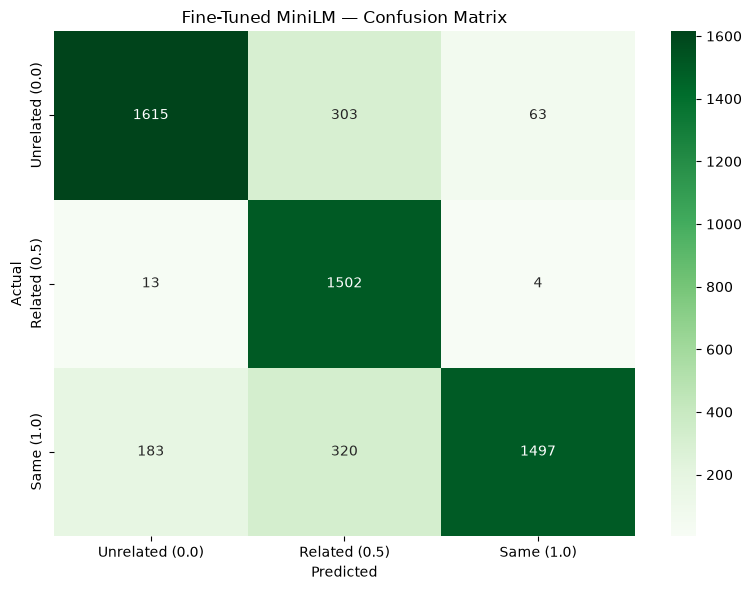

Saved: minilm_confusion_matrix.png


In [ ]:
# Confusion Matrix

cm = confusion_matrix(true_bucket_idx, pred_bucket_idx)
 
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens',
            xticklabels=label_names, yticklabels=label_names)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Fine-Tuned MiniLM — Confusion Matrix')
plt.tight_layout()
plt.savefig('minilm_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: minilm_confusion_matrix.png")
 

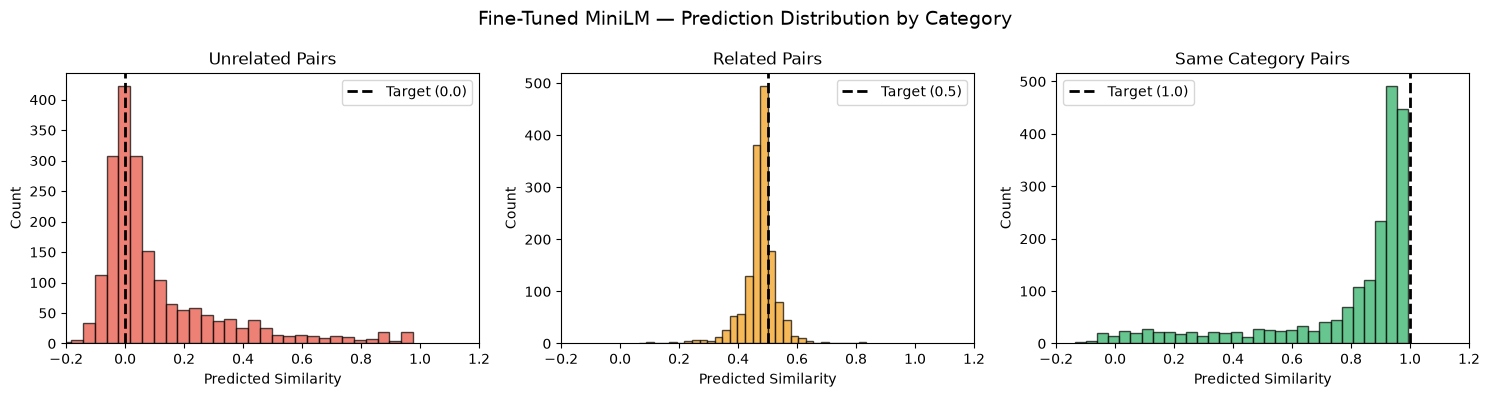

Saved: minilm_prediction_dist.png


In [14]:
# Prediction Distribution

 
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
 
for i, (label_val, name) in enumerate([(0.0, 'Unrelated'), (0.5, 'Related'), (1.0, 'Same Category')]):
    mask = test_labels == label_val
    preds = post_ft_predictions[mask]
    axes[i].hist(preds, bins=30, color=['#e74c3c', '#f39c12', '#27ae60'][i], alpha=0.7, edgecolor='black')
    axes[i].axvline(x=label_val, color='black', linestyle='--', linewidth=2, label=f'Target ({label_val})')
    axes[i].set_xlabel('Predicted Similarity')
    axes[i].set_ylabel('Count')
    axes[i].set_title(f'{name} Pairs')
    axes[i].legend()
    axes[i].set_xlim(-0.2, 1.2)
 
plt.suptitle('Fine-Tuned MiniLM — Prediction Distribution by Category', fontsize=14)
plt.tight_layout()
plt.savefig('minilm_prediction_dist.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: minilm_prediction_dist.png")

## Before vs After Fine-Tuning Comparison
Side-by-side comparison showing the impact of fine-tuning:
- Accuracy: 33.2% → 83.9% (+50.7 percentage points)
- Demonstrates that domain-specific fine-tuning is essential — the pre-trained model's generic embeddings could not distinguish resume-job relevance without adaptation

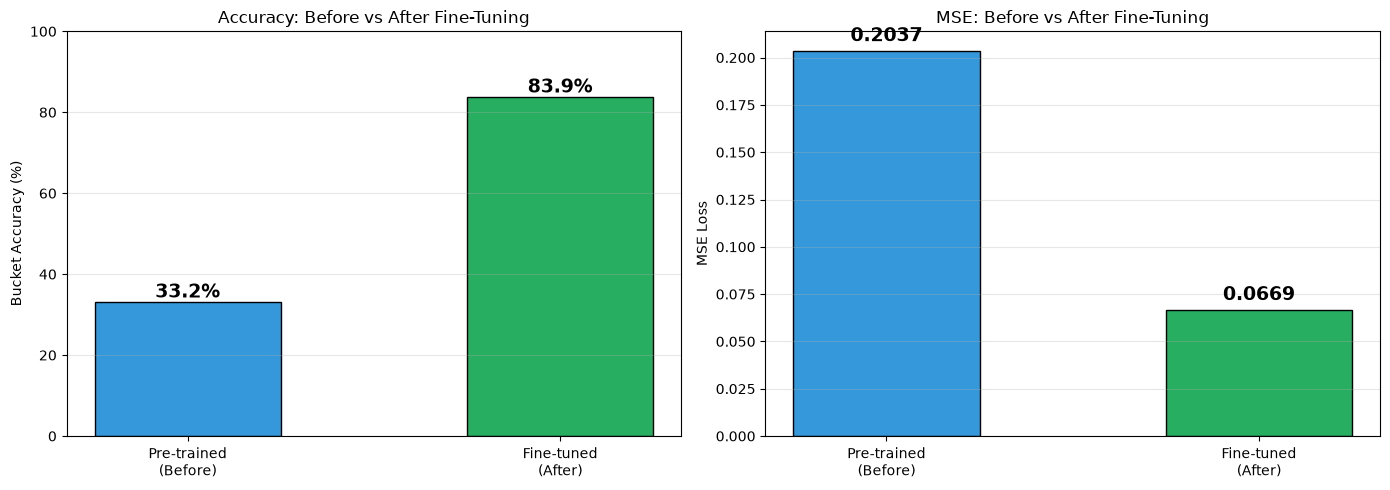

Saved: minilm_before_after_comparison.png


In [15]:
# Before vs After Fine-Tuning Comparison

 
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
 
categories_plot = ['Pre-trained\n(Before)', 'Fine-tuned\n(After)']
accuracies = [pre_ft_accuracy * 100, post_ft_accuracy * 100]
colors = ['#3498db', '#27ae60']
bars = axes[0].bar(categories_plot, accuracies, color=colors, edgecolor='black', width=0.5)
for bar, acc in zip(bars, accuracies):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
                 f'{acc:.1f}%', ha='center', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Bucket Accuracy (%)')
axes[0].set_title('Accuracy: Before vs After Fine-Tuning')
axes[0].set_ylim(0, 100)
axes[0].grid(axis='y', alpha=0.3)
 
mse_values = [pre_ft_mse, post_ft_mse]
bars2 = axes[1].bar(categories_plot, mse_values, color=colors, edgecolor='black', width=0.5)
for bar, mse in zip(bars2, mse_values):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                 f'{mse:.4f}', ha='center', fontsize=14, fontweight='bold')
axes[1].set_ylabel('MSE Loss')
axes[1].set_title('MSE: Before vs After Fine-Tuning')
axes[1].grid(axis='y', alpha=0.3)
 
plt.tight_layout()
plt.savefig('minilm_before_after_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: minilm_before_after_comparison.png")

## Final Summary
Compares all three approaches:
- **LSTM baseline (Part 1):** 65.1% accuracy — trained from scratch, no pre-trained knowledge
- **Pre-trained Sentence Transformer:** 33.2% — generic embeddings without domain adaptation
- **Fine-tuned Sentence Transformer (Part 2):** 83.9% — best performance, +18.8 points over LSTM

The fine-tuned model is saved to `fine_tuned_minilm/` (~88MB) and used in the LangGraph pipeline and Streamlit web app for live job matching.

In [16]:
# Save Final Summary 

lstm_accuracy = 0.65  # From Part 1

print("=" * 60)
print("         PART 2 COMPLETE — FINAL SUMMARY")
print("=" * 60)

print(f"\n  {'Model':<30} {'Accuracy':>10} {'MSE':>10}")
print(f"  {'-'*50}")
print(f"  {'Siamese LSTM (baseline)':<30} {lstm_accuracy*100:>9.1f}% {'N/A':>10}")
print(f"  {'MiniLM Pre-trained':<30} {pre_ft_accuracy*100:>9.1f}% {pre_ft_mse:>10.4f}")
print(f"  {'MiniLM Fine-tuned':<30} {post_ft_accuracy*100:>9.1f}% {post_ft_mse:>10.4f}")

print(f"\n  Ranking Metrics (Fine-tuned):")
print(f"  {'MRR':<30} {ft_mrr:>10.4f}")
print(f"  {'NDCG@10':<30} {ft_ndcg:>10.4f}")

improvement = (post_ft_accuracy - lstm_accuracy) * 100
print(f"\n  Improvement over LSTM baseline: +{improvement:.1f}%")
print("=" * 60)

final_results = {
    'lstm_baseline_accuracy': lstm_accuracy,
    'pretrained_accuracy': float(pre_ft_accuracy),
    'pretrained_mse': float(pre_ft_mse),
    'finetuned_accuracy': float(post_ft_accuracy),
    'finetuned_mse': float(post_ft_mse),
    'finetuned_mrr': float(ft_mrr),
    'finetuned_ndcg': float(ft_ndcg),
}

with open('final_model_comparison.json', 'w') as f:
    json.dump(final_results, f, indent=2)

import pickle
with open('test_pairs.pkl', 'wb') as f:
    pickle.dump((test_pairs, test_sentences1, test_sentences2, test_labels), f)

print("\nSaved: final_model_comparison.json")
print("Saved: test_pairs.pkl (test set locked for future use)")

         PART 2 COMPLETE — FINAL SUMMARY

  Model                            Accuracy        MSE
  --------------------------------------------------
  Siamese LSTM (baseline)             65.0%        N/A
  MiniLM Pre-trained                  33.2%     0.2037
  MiniLM Fine-tuned                   83.9%     0.0669

  Ranking Metrics (Fine-tuned):
  MRR                                0.9259
  NDCG@10                            0.9371

  Improvement over LSTM baseline: +18.9%

Saved: final_model_comparison.json
Saved: test_pairs.pkl (test set locked for future use)
